In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

# Dataset stored locally — mount your drive and update BASE path below

Mounted at /content/drive


In [ ]:
# NOTE: Update BASE path to your own dataset location
# Dataset not included — clinical data from NIT Calicut

In [ ]:
!pip install -q transformers datasets accelerate
!pip install -q git+https://github.com/facebookresearch/segment-anything.git
!pip install -q git+https://github.com/AIM-Harvard/pyradiomics.git
!pip install -q SimpleITK shap scikit-learn xgboost timm
!pip install -q matplotlib seaborn pandas numpy

print("All installations complete!")

  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 9.1 MB/s eta 0:00:00
All installations complete!


In [ ]:
import torch
import os

# Check GPU
print(f"GPU available: {torch.cuda.is_available()}")
print(f"GPU name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

# ── ALL PATHS — everything points to your existing Drive structure ──
BASE        = '/content/drive/MyDrive/Ultrasound_Internship'
DATA_DIR    = f'{BASE}/dataset/gmc/data'          # grade1/ grade2/ grade3/ grade4/
FLAT_DIR    = '/content/gmc_flat'                  # temporary flat folder (rebuilt each session)
CSV_PATH    = f'{BASE}/outputs/pyradiomics_features.csv'   # already generated by AI_Project_2
VIT_MODEL   = f'{BASE}/models/ViT_Heckmatt_Model'          # already trained ViT

REVIT_BASE  = f'{BASE}/revit_project'
MODEL_SAVE  = f'{REVIT_BASE}/models'
OUTPUT_SAVE = f'{REVIT_BASE}/outputs'

# Create temp dirs
os.makedirs(FLAT_DIR, exist_ok=True)
os.makedirs(MODEL_SAVE, exist_ok=True)
os.makedirs(OUTPUT_SAVE, exist_ok=True)

print("\nAll paths configured:")
print(f"  Data:        {DATA_DIR}")
print(f"  CSV:         {CSV_PATH}")
print(f"  ViT Model:   {VIT_MODEL}")
print(f"  ReViT saves: {MODEL_SAVE}")

GPU available: True
GPU name: Tesla T4

All paths configured:
  Data:        /content/drive/MyDrive/Ultrasound_Internship/dataset/gmc/data
  CSV:         /content/drive/MyDrive/Ultrasound_Internship/outputs/pyradiomics_features.csv
  ViT Model:   /content/drive/MyDrive/Ultrasound_Internship/models/ViT_Heckmatt_Model
  ReViT saves: /content/drive/MyDrive/Ultrasound_Internship/revit_project/models


In [ ]:
import shutil

grade_map = {'grade1':'H1', 'grade2':'H2', 'grade3':'H3', 'grade4':'H4'}

if len(os.listdir(FLAT_DIR)) == 0:
    print("Rebuilding gmc_flat...")
    for folder, tag in grade_map.items():
        folder_path = os.path.join(DATA_DIR, folder)
        for fname in os.listdir(folder_path):
            if fname.lower().endswith(('.png','.jpg','.bmp','.tif','.tiff')):
                shutil.copy(os.path.join(folder_path, fname),
                            os.path.join(FLAT_DIR, f"{tag}_{fname}"))
    print(f"Done! {len(os.listdir(FLAT_DIR))} images ready")
else:
    print(f"gmc_flat already has {len(os.listdir(FLAT_DIR))} images")

Rebuilding gmc_flat...
Done! 305 images ready


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load the CSV already generated by AI_Project_2
df = pd.read_csv(CSV_PATH)
print(f"Dataset shape: {df.shape}")
print(f"Columns: Filename, Heckmatt_Grade + {df.shape[1]-2} radiomics features")
print(f"\nGrade distribution:")
print(df['Heckmatt_Grade'].value_counts().sort_index())

# Separate features and labels
feature_cols = [c for c in df.columns if c.startswith('original_')]
X_rad = df[feature_cols].fillna(df[feature_cols].median()).values.astype(np.float32)
filenames = df['Filename'].values

# Binary labels: Grade1=Normal(0), Grades2-4=Abnormal(1)
y_binary = (df['Heckmatt_Grade'] > 1).astype(int).values

print(f"\nRadiomics feature count: {X_rad.shape[1]}")
print(f"Normal (0): {(y_binary==0).sum()} | Abnormal (1): {(y_binary==1).sum()}")

# Normalise radiomics features
scaler = StandardScaler()
X_rad_scaled = scaler.fit_transform(X_rad)

# Save scaler for later inference
import pickle
with open(f'{MODEL_SAVE}/rad_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("\nScaler saved. Data ready!")

Dataset shape: (305, 95)
Columns: Filename, Heckmatt_Grade + 93 radiomics features

Grade distribution:
Heckmatt_Grade
1     50
2    105
3     84
4     66
Name: count, dtype: int64

Radiomics feature count: 93
Normal (0): 50 | Abnormal (1): 255

Scaler saved. Data ready!


In [ ]:
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class HeckmatFusionDataset(Dataset):
    """
    Returns (image_tensor, radiomics_tensor, label) for each sample.
    image_tensor  : 224x224 RGB normalised for ViT
    radiomics_tensor: scaled 93-dim float vector
    label         : 0=Normal, 1=Abnormal
    """
    def __init__(self, filenames, X_rad_scaled, y_labels, flat_dir):
        self.filenames   = filenames
        self.radiomics   = torch.tensor(X_rad_scaled, dtype=torch.float32)
        self.labels      = torch.tensor(y_labels,     dtype=torch.long)
        self.flat_dir    = flat_dir
        self.transform   = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],   # ImageNet stats (ViT pre-training)
                std =[0.229, 0.224, 0.225]
            )
        ])

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname    = self.filenames[idx]
        img_path = os.path.join(self.flat_dir, fname)

        # Load image
        img = cv2.imread(img_path)
        if img is None:
            # Fallback: black image if file missing
            img = np.zeros((224, 224, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img_pil    = Image.fromarray(img)
        img_tensor = self.transform(img_pil)

        return img_tensor, self.radiomics[idx], self.labels[idx]

# ── Train / Test split (stratified, same 80/20 as before) ──
from sklearn.model_selection import train_test_split

idx = np.arange(len(filenames))
train_idx, test_idx = train_test_split(
    idx, test_size=0.2, random_state=42, stratify=y_binary
)

train_ds = HeckmatFusionDataset(
    filenames[train_idx], X_rad_scaled[train_idx], y_binary[train_idx], FLAT_DIR)
test_ds  = HeckmatFusionDataset(
    filenames[test_idx],  X_rad_scaled[test_idx],  y_binary[test_idx],  FLAT_DIR)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=8, shuffle=False, num_workers=2)

print(f"Train samples: {len(train_ds)}  |  Test samples: {len(test_ds)}")

# Quick sanity check — grab one batch
imgs, rads, labs = next(iter(train_loader))
print(f"Image batch shape:    {imgs.shape}")   # [8, 3, 224, 224]
print(f"Radiomics batch shape: {rads.shape}")  # [8, 93]
print(f"Labels batch shape:    {labs.shape}")  # [8]
print("\nDataset ready!")

Train samples: 244  |  Test samples: 61
Image batch shape:    torch.Size([8, 3, 224, 224])
Radiomics batch shape: torch.Size([8, 93])
Labels batch shape:    torch.Size([8])

Dataset ready!


In [ ]:
import torch.nn as nn

class RadiomicsEmbedder(nn.Module):
    """
    Projects 93-dim radiomics vector into 768-dim embedding space
    (same dimension as ViT hidden states) so they can be fused.

    Architecture:
        93 → 256 → LayerNorm → GELU → 768
    """
    def __init__(self, input_dim=93, embed_dim=768, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, embed_dim),
            nn.LayerNorm(embed_dim)     # final norm before injection into ViT
        )

    def forward(self, x):
        return self.net(x)   # [batch, 768]

# Test it
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
embedder_test = RadiomicsEmbedder(
    input_dim=X_rad_scaled.shape[1]   # 93 features
).to(device)

dummy_rad = torch.randn(4, X_rad_scaled.shape[1]).to(device)
out = embedder_test(dummy_rad)
print(f"RadiomicsEmbedder test:")
print(f"  Input shape:  {dummy_rad.shape}")    # [4, 93]
print(f"  Output shape: {out.shape}")           # [4, 768]
print(f"\nRadiomicsEmbedder working correctly!")
print(f"Radiomics feature count: {X_rad_scaled.shape[1]}")

RadiomicsEmbedder test:
  Input shape:  torch.Size([4, 93])
  Output shape: torch.Size([4, 768])

RadiomicsEmbedder working correctly!
Radiomics feature count: 93


In [ ]:
class CrossAttentionFusion(nn.Module):
    """
    Lets radiomics and ViT patch tokens attend to each other.

    What happens inside:
    1. Radiomics embedding queries all 197 ViT patch tokens
       → radiomics learns WHICH image regions match its texture features
    2. ViT CLS token queries the radiomics embedding
       → visual features learn WHICH radiomics biomarkers support what it sees
    3. Both enriched outputs are concatenated → 1536-dim fused vector
    """
    def __init__(self, embed_dim=768, num_heads=8, dropout=0.1):
        super().__init__()

        # Radiomics attends to ViT patches
        self.rad_to_vit_attn = nn.MultiheadAttention(
            embed_dim, num_heads, dropout=dropout, batch_first=True
        )
        # ViT CLS attends to radiomics
        self.vit_to_rad_attn = nn.MultiheadAttention(
            embed_dim, num_heads, dropout=dropout, batch_first=True
        )

        # Layer norms for stability
        self.norm_rad = nn.LayerNorm(embed_dim)
        self.norm_vit = nn.LayerNorm(embed_dim)

        # Small feedforward after attention (like transformer FFN)
        self.ffn_rad = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim * 2, embed_dim)
        )
        self.ffn_vit = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim * 2, embed_dim)
        )
        self.norm_rad2 = nn.LayerNorm(embed_dim)
        self.norm_vit2 = nn.LayerNorm(embed_dim)

    def forward(self, rad_emb, vit_tokens):
        """
        rad_emb   : [batch, 768]      — radiomics embedding
        vit_tokens: [batch, 197, 768] — all ViT patch tokens including CLS
        Returns   : [batch, 1536]     — concatenated fused vector
        """
        # Expand rad_emb to sequence format for attention
        rad_seq = rad_emb.unsqueeze(1)          # [batch, 1, 768]
        cls_tok = vit_tokens[:, 0:1, :]         # [batch, 1, 768]

        # 1. Radiomics queries ViT patches (with residual + norm)
        rad_att, _ = self.rad_to_vit_attn(
            query=rad_seq,
            key=vit_tokens,
            value=vit_tokens
        )
        rad_out = self.norm_rad(rad_seq + rad_att)              # residual
        rad_out = self.norm_rad2(rad_out + self.ffn_rad(rad_out))  # FFN
        rad_out = rad_out.squeeze(1)             # [batch, 768]

        # 2. ViT CLS queries radiomics (with residual + norm)
        vit_att, _ = self.vit_to_rad_attn(
            query=cls_tok,
            key=rad_seq,
            value=rad_seq
        )
        vit_out = self.norm_vit(cls_tok + vit_att)
        vit_out = self.norm_vit2(vit_out + self.ffn_vit(vit_out))
        vit_out = vit_out.squeeze(1)             # [batch, 768]

        # 3. Concatenate both enriched representations
        fused = torch.cat([rad_out, vit_out], dim=-1)  # [batch, 1536]
        return fused

# Quick test
ca_test = CrossAttentionFusion().to(device)
dummy_rad_emb  = torch.randn(4, 768).to(device)
dummy_vit_toks = torch.randn(4, 197, 768).to(device)
fused_out = ca_test(dummy_rad_emb, dummy_vit_toks)
print(f"CrossAttentionFusion test:")
print(f"  Radiomics emb input:  {dummy_rad_emb.shape}")
print(f"  ViT tokens input:     {dummy_vit_toks.shape}")
print(f"  Fused output shape:   {fused_out.shape}")   # [4, 1536]
print("\nCrossAttentionFusion working correctly!")

CrossAttentionFusion test:
  Radiomics emb input:  torch.Size([4, 768])
  ViT tokens input:     torch.Size([4, 197, 768])
  Fused output shape:   torch.Size([4, 1536])

CrossAttentionFusion working correctly!


In [ ]:
from transformers import ViTModel

class ReViT(nn.Module):
    """
    Radiomics-Enhanced Vision Transformer.

    Pipeline:
    1. ViT encoder extracts patch token sequence from image
    2. RadiomicsEmbedder projects 93 features → 768-dim
    3. CrossAttentionFusion enriches both representations
    4. Classifier head makes final prediction from fused vector

    The key innovation: radiomics and visual features
    attend to each other before classification — they
    do NOT just get averaged at the end like before.
    """
    def __init__(self, rad_input_dim=93, num_classes=2,
                 embed_dim=768, num_heads=8, dropout=0.2):
        super().__init__()

        # ── ViT backbone (load pretrained weights) ──
        print("Loading ViT backbone...")
        self.vit = ViTModel.from_pretrained(
            "google/vit-base-patch16-224-in21k"
        )

        # ── Radiomics embedder ──
        self.rad_embedder = RadiomicsEmbedder(
            input_dim=rad_input_dim,
            embed_dim=embed_dim,
            dropout=dropout
        )

        # ── Cross-attention fusion ──
        self.cross_attn = CrossAttentionFusion(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout
        )

        # ── Classification head ──
        # Input: 1536 (768 from radiomics path + 768 from ViT path)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim * 2, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, images, radiomics):
        """
        images   : [batch, 3, 224, 224]
        radiomics: [batch, 93]
        Returns  : logits [batch, 2]
        """
        # 1. Extract ViT patch tokens
        vit_out    = self.vit(pixel_values=images)
        vit_tokens = vit_out.last_hidden_state   # [batch, 197, 768]

        # 2. Embed radiomics into 768-dim space
        rad_emb = self.rad_embedder(radiomics)   # [batch, 768]

        # 3. Cross-attention fusion
        fused = self.cross_attn(rad_emb, vit_tokens)   # [batch, 1536]

        # 4. Classify
        logits = self.classifier(fused)   # [batch, 2]
        return logits

    def get_attention_weights(self, images, radiomics):
        """For SHAP/explainability: returns attention weights."""
        vit_out    = self.vit(pixel_values=images,
                              output_attentions=True)
        vit_tokens = vit_out.last_hidden_state
        rad_emb    = self.rad_embedder(radiomics)
        return vit_out.attentions   # per-layer attention maps


# ── Build model and print summary ──
rad_dim = X_rad_scaled.shape[1]   # 93

model = ReViT(
    rad_input_dim=rad_dim,
    num_classes=2,
    embed_dim=768,
    num_heads=8,
    dropout=0.2
).to(device)

# Count parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nReViT Model built successfully!")
print(f"  Total parameters:     {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Device: {device}")

Loading ViT backbone...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]


ReViT Model built successfully!
  Total parameters:     96,920,706
  Trainable parameters: 96,920,706
  Device: cuda


In [ ]:
# Grab one batch and run it through the full model
model.eval()
with torch.no_grad():
    test_imgs, test_rads, test_labs = next(iter(train_loader))
    test_imgs = test_imgs.to(device)
    test_rads = test_rads.to(device)

    logits = model(test_imgs, test_rads)
    probs  = torch.softmax(logits, dim=-1)

print("Full forward pass test:")
print(f"  Input images shape:    {test_imgs.shape}")   # [8, 3, 224, 224]
print(f"  Input radiomics shape: {test_rads.shape}")   # [8, 93]
print(f"  Output logits shape:   {logits.shape}")      # [8, 2]
print(f"  Output probs shape:    {probs.shape}")       # [8, 2]
print(f"\nSample predictions (Normal prob, Abnormal prob):")
for i in range(4):
    print(f"  Sample {i+1}: Normal={probs[i,0]:.3f}  Abnormal={probs[i,1]:.3f}  "
          f"True label={'Normal' if test_labs[i]==0 else 'Abnormal'}")

print("\nReViT full pipeline verified! Ready for training.")

Full forward pass test:
  Input images shape:    torch.Size([8, 3, 224, 224])
  Input radiomics shape: torch.Size([8, 93])
  Output logits shape:   torch.Size([8, 2])
  Output probs shape:    torch.Size([8, 2])

Sample predictions (Normal prob, Abnormal prob):
  Sample 1: Normal=0.484  Abnormal=0.516  True label=Abnormal
  Sample 2: Normal=0.517  Abnormal=0.483  True label=Abnormal
  Sample 3: Normal=0.524  Abnormal=0.476  True label=Abnormal
  Sample 4: Normal=0.555  Abnormal=0.445  True label=Abnormal

ReViT full pipeline verified! Ready for training.


In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

# ── Class weights (handle imbalance: 50 Normal vs 255 Abnormal) ──
normal_count   = (y_binary == 0).sum()
abnormal_count = (y_binary == 1).sum()
total          = len(y_binary)

weight_normal   = total / (2 * normal_count)
weight_abnormal = total / (2 * abnormal_count)
class_weights   = torch.tensor([weight_normal, weight_abnormal],
                                dtype=torch.float32).to(device)

print(f"Class weights → Normal: {weight_normal:.3f}  Abnormal: {weight_abnormal:.3f}")

# ── Loss function (weighted cross entropy) ──
criterion = nn.CrossEntropyLoss(weight=class_weights)

# ── Optimizer: different learning rates for ViT vs new layers ──
# ViT backbone gets a SMALL lr (it's already pretrained, fine-tune gently)
# New layers (embedder, cross-attention, classifier) get LARGER lr
optimizer = AdamW([
    {"params": model.vit.parameters(),         "lr": 2e-5,  "weight_decay": 0.01},
    {"params": model.rad_embedder.parameters(),"lr": 1e-4,  "weight_decay": 0.01},
    {"params": model.cross_attn.parameters(),  "lr": 1e-4,  "weight_decay": 0.01},
    {"params": model.classifier.parameters(),  "lr": 1e-4,  "weight_decay": 0.01},
])

# ── Cosine LR scheduler (smoothly reduces lr over epochs) ──
NUM_EPOCHS = 15
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

print(f"Optimizer ready with differential learning rates")
print(f"  ViT backbone lr:    2e-5  (gentle fine-tuning)")
print(f"  New layers lr:      1e-4  (faster learning)")
print(f"  Total epochs:       {NUM_EPOCHS}")
print(f"  Loss:               Weighted CrossEntropy")
print(f"  Scheduler:          CosineAnnealingLR")

Class weights → Normal: 3.050  Abnormal: 0.598
Optimizer ready with differential learning rates
  ViT backbone lr:    2e-5  (gentle fine-tuning)
  New layers lr:      1e-4  (faster learning)
  Total epochs:       15
  Loss:               Weighted CrossEntropy
  Scheduler:          CosineAnnealingLR


In [ ]:
from sklearn.metrics import f1_score, accuracy_score
import time

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []

    for imgs, rads, labels in loader:
        imgs   = imgs.to(device)
        rads   = rads.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(imgs, rads)
        loss   = criterion(logits, labels)
        loss.backward()

        # Gradient clipping (prevents exploding gradients in attention layers)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, acc, f1


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []

    with torch.no_grad():
        for imgs, rads, labels in loader:
            imgs   = imgs.to(device)
            rads   = rads.to(device)
            labels = labels.to(device)

            logits = model(imgs, rads)
            loss   = criterion(logits, labels)

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, acc, f1, all_preds, all_labels


# ── Training loop with best model saving ──
print("Starting ReViT Training...")
print("="*65)

best_val_f1   = 0.0
best_epoch    = 0
train_history = []

for epoch in range(1, NUM_EPOCHS + 1):
    start = time.time()

    train_loss, train_acc, train_f1 = train_one_epoch(
        model, train_loader, optimizer, criterion, device)

    val_loss, val_acc, val_f1, _, _ = evaluate(
        model, test_loader, criterion, device)

    scheduler.step()
    elapsed = time.time() - start

    # Save history
    train_history.append({
        "epoch": epoch,
        "train_loss": train_loss, "train_acc": train_acc, "train_f1": train_f1,
        "val_loss":   val_loss,   "val_acc":   val_acc,   "val_f1":   val_f1
    })

    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch  = epoch
        torch.save(model.state_dict(),
                   f"{MODEL_SAVE}/revit_best.pt")
        saved_marker = " ← BEST SAVED"
    else:
        saved_marker = ""

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.3f}  F1: {train_f1:.3f} | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.3f}  F1: {val_f1:.3f} | "
          f"{elapsed:.0f}s{saved_marker}")

print("="*65)
print(f"\nTraining complete!")
print(f"Best model → Epoch {best_epoch}  |  Val Macro F1: {best_val_f1:.4f}")
print(f"Saved to: {MODEL_SAVE}/revit_best.pt")

Starting ReViT Training...
Epoch 01/15 | Train Loss: 0.5429  Acc: 0.734  F1: 0.647 | Val Loss: 0.6959  Acc: 0.754  F1: 0.623 | 13s ← BEST SAVED
Epoch 02/15 | Train Loss: 0.5147  Acc: 0.799  F1: 0.675 | Val Loss: 0.6635  Acc: 0.705  F1: 0.619 | 11s
Epoch 03/15 | Train Loss: 0.4666  Acc: 0.791  F1: 0.717 | Val Loss: 0.6839  Acc: 0.738  F1: 0.646 | 11s ← BEST SAVED
Epoch 04/15 | Train Loss: 0.5375  Acc: 0.844  F1: 0.745 | Val Loss: 0.6348  Acc: 0.738  F1: 0.661 | 12s ← BEST SAVED
Epoch 05/15 | Train Loss: 0.4949  Acc: 0.877  F1: 0.792 | Val Loss: 1.0516  Acc: 0.803  F1: 0.516 | 13s
Epoch 06/15 | Train Loss: 0.4133  Acc: 0.902  F1: 0.827 | Val Loss: 1.1338  Acc: 0.754  F1: 0.569 | 13s
Epoch 07/15 | Train Loss: 0.4387  Acc: 0.914  F1: 0.838 | Val Loss: 0.7993  Acc: 0.820  F1: 0.657 | 13s
Epoch 08/15 | Train Loss: 0.1389  Acc: 0.971  F1: 0.949 | Val Loss: 1.1942  Acc: 0.836  F1: 0.640 | 12s
Epoch 09/15 | Train Loss: 0.0613  Acc: 0.980  F1: 0.964 | Val Loss: 0.7591  Acc: 0.836  F1: 0.756 | 12

       ReViT FINAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       0.57      0.80      0.67        10
    Abnormal       0.96      0.88      0.92        51

    accuracy                           0.87        61
   macro avg       0.76      0.84      0.79        61
weighted avg       0.89      0.87      0.88        61

Overall Accuracy : 0.8689
ROC-AUC          : 0.8843
Macro F1         : 0.7925


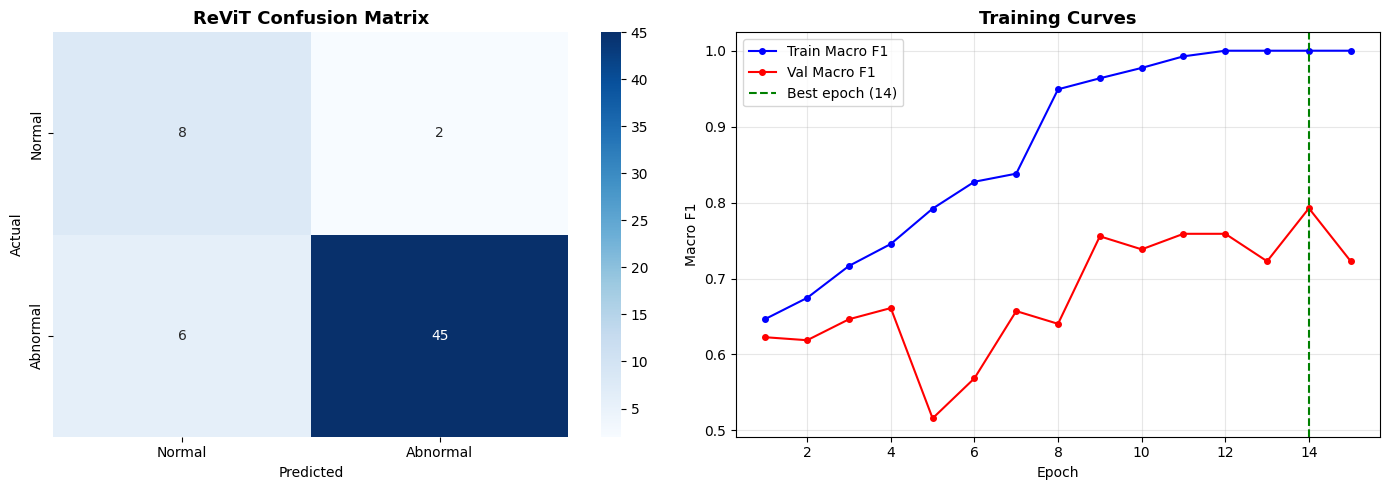


Plot saved to /content/drive/MyDrive/Ultrasound_Internship/revit_project/outputs/revit_results.png


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load best saved model
model.load_state_dict(torch.load(f"{MODEL_SAVE}/revit_best.pt"))
model.eval()

# Get all predictions and probabilities
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, rads, labels in test_loader:
        imgs   = imgs.to(device)
        rads   = rads.to(device)
        logits = model(imgs, rads)
        probs  = torch.softmax(logits, dim=-1)

        all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())   # abnormal probability

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# ── Classification Report ──
print("="*55)
print("       ReViT FINAL CLASSIFICATION REPORT")
print("="*55)
print(classification_report(
    all_labels, all_preds,
    target_names=["Normal", "Abnormal"]
))
acc = accuracy_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)
f1  = f1_score(all_labels, all_preds, average='macro')
print(f"Overall Accuracy : {acc:.4f}")
print(f"ROC-AUC          : {auc:.4f}")
print(f"Macro F1         : {f1:.4f}")
print("="*55)

# ── Confusion Matrix ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Normal","Abnormal"],
            yticklabels=["Normal","Abnormal"],
            ax=axes[0])
axes[0].set_title("ReViT Confusion Matrix", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# ── Training curves ──
epochs     = [h["epoch"]    for h in train_history]
train_f1s  = [h["train_f1"] for h in train_history]
val_f1s    = [h["val_f1"]   for h in train_history]
train_accs = [h["train_acc"] for h in train_history]
val_accs   = [h["val_acc"]   for h in train_history]

axes[1].plot(epochs, train_f1s, 'b-o', label='Train Macro F1', markersize=4)
axes[1].plot(epochs, val_f1s,   'r-o', label='Val Macro F1',   markersize=4)
axes[1].axvline(x=best_epoch, color='green', linestyle='--', label=f'Best epoch ({best_epoch})')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro F1")
axes[1].set_title("Training Curves", fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_SAVE}/revit_results.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"\nPlot saved to {OUTPUT_SAVE}/revit_results.png")

Computing SHAP values for radiomics features...
(This takes 2-3 minutes)
SHAP values computed!
Shape: (20, 93)


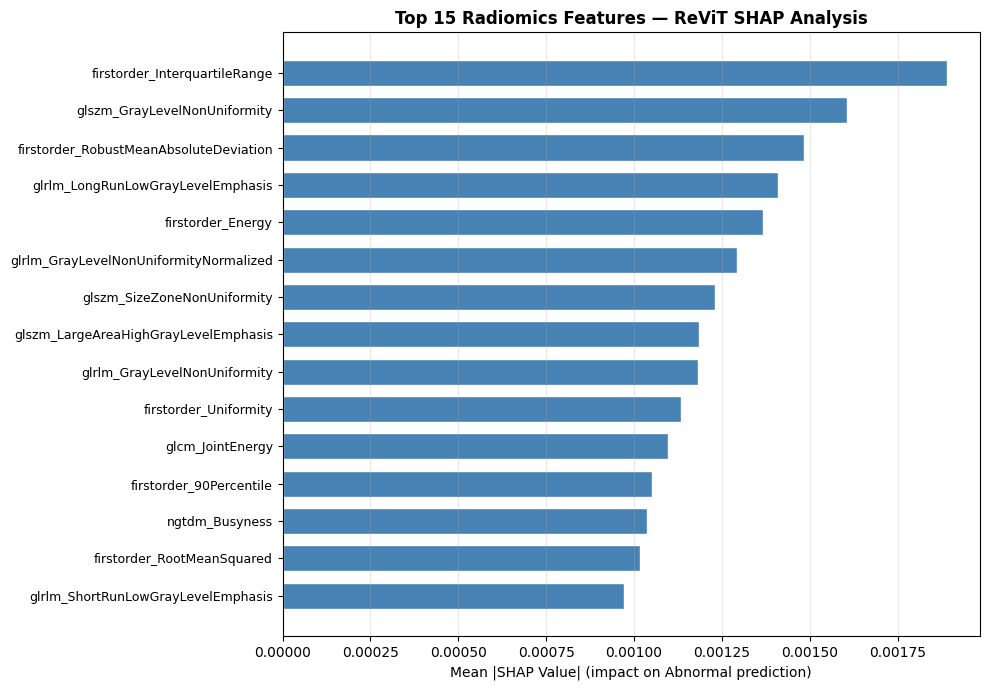

Saved to /content/drive/MyDrive/Ultrasound_Internship/revit_project/outputs/shap_radiomics_importance.png


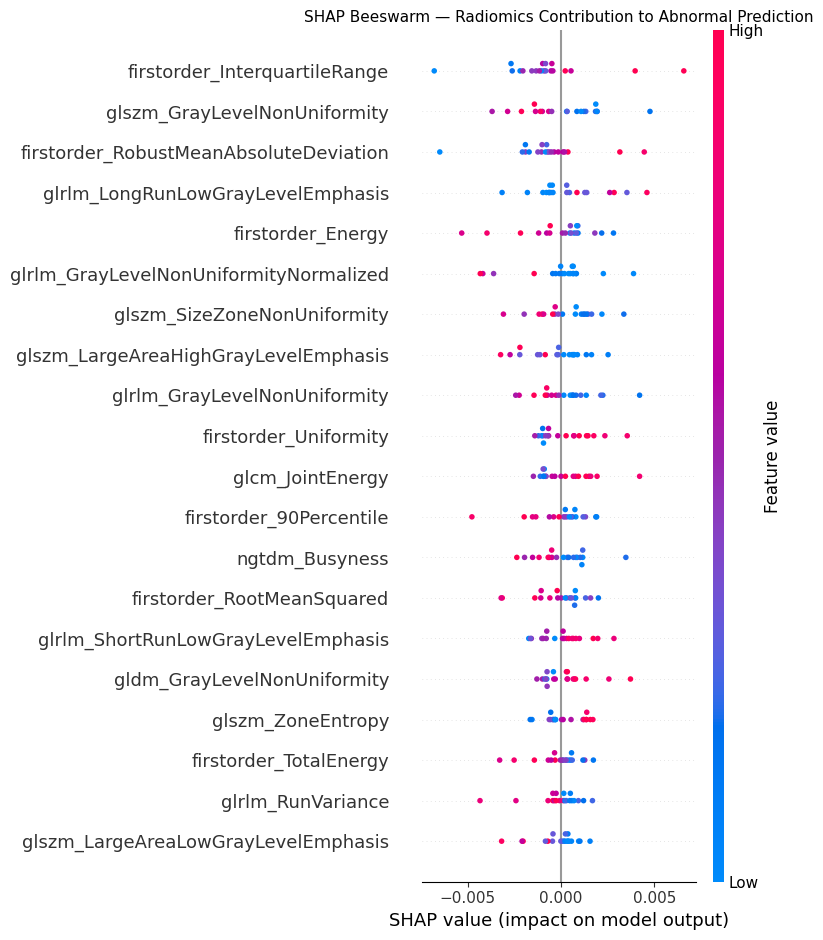

Saved to /content/drive/MyDrive/Ultrasound_Internship/revit_project/outputs/shap_beeswarm.png


In [ ]:
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Wrapper: SHAP needs a simple function that takes numpy → numpy ──
# We freeze the ViT part and only explain the radiomics contribution

class RadiomicsOnlyWrapper(nn.Module):
    """
    Wraps ReViT but accepts ONLY radiomics as input.
    ViT processes a fixed reference image so SHAP can
    isolate the radiomics contribution to the prediction.
    """
    def __init__(self, revit_model, reference_image):
        super().__init__()
        self.model     = revit_model
        self.ref_image = reference_image  # [1, 3, 224, 224]

    def forward(self, radiomics_batch):
        batch_size = radiomics_batch.shape[0]
        # Repeat reference image for the whole batch
        imgs = self.ref_image.repeat(batch_size, 1, 1, 1).to(device)
        rads = radiomics_batch.to(device)
        logits = self.model(imgs, rads)
        return torch.softmax(logits, dim=-1)

# Get a reference image (use first test image)
ref_img, _, _ = test_ds[0]
ref_img = ref_img.unsqueeze(0).to(device)

rad_wrapper = RadiomicsOnlyWrapper(model, ref_img).to(device)
rad_wrapper.eval()

# ── Build SHAP background and test sets ──
# Background = small sample of training radiomics (SHAP baseline)
background_rad = torch.tensor(
    X_rad_scaled[train_idx[:30]], dtype=torch.float32
).to(device)

test_rad_shap = torch.tensor(
    X_rad_scaled[test_idx[:20]], dtype=torch.float32
).to(device)

# ── Run SHAP GradientExplainer ──
print("Computing SHAP values for radiomics features...")
print("(This takes 2-3 minutes)")

explainer  = shap.GradientExplainer(rad_wrapper, background_rad)
shap_vals  = explainer.shap_values(test_rad_shap)
# shap_vals is a list: [shap_for_Normal, shap_for_Abnormal]
# We care about Abnormal class (index 1)
#remember a small dimension modification was done here
shap_abnormal = shap_vals[:, :, 1]   # [20, 93] — Abnormal class, all samples, all features

print(f"SHAP values computed!")
print(f"Shape: {shap_abnormal.shape}")   # [20, 93]

# ── Plot 1: Global feature importance bar chart ──
feature_names = feature_cols   # the 93 radiomics column names

mean_shap = np.abs(shap_abnormal).mean(axis=0)   # [93]
top15_idx  = np.argsort(mean_shap)[::-1][:15]
top15_vals = mean_shap[top15_idx]
top15_names = [feature_names[i].replace('original_','') for i in top15_idx]

# Convert to plain lists to avoid numpy broadcast issues
top15_vals_list  = list(top15_vals)
top15_names_list = list(top15_names)

fig, ax = plt.subplots(figsize=(10, 7))
y_pos = list(range(15))
ax.barh(y_pos, top15_vals_list[::-1],
        color='steelblue', edgecolor='white', height=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(top15_names_list[::-1], fontsize=9)
ax.set_xlabel("Mean |SHAP Value| (impact on Abnormal prediction)", fontsize=10)
ax.set_title("Top 15 Radiomics Features — ReViT SHAP Analysis", fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_SAVE}/shap_radiomics_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {OUTPUT_SAVE}/shap_radiomics_importance.png")

# ── Plot 2: SHAP beeswarm (shows direction of each feature) ──
shap.summary_plot(
    shap_abnormal,
    test_rad_shap.cpu().numpy(),
    feature_names=[f.replace('original_','') for f in feature_names],
    max_display=20,
    show=False
)
plt.title("SHAP Beeswarm — Radiomics Contribution to Abnormal Prediction", fontsize=11)
plt.tight_layout()
plt.savefig(f"{OUTPUT_SAVE}/shap_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {OUTPUT_SAVE}/shap_beeswarm.png")

mean_shap shape: (2,)
top15_idx shape: (2,)
top15_vals: [0.00025231 0.00025231]
len top15_names: 2


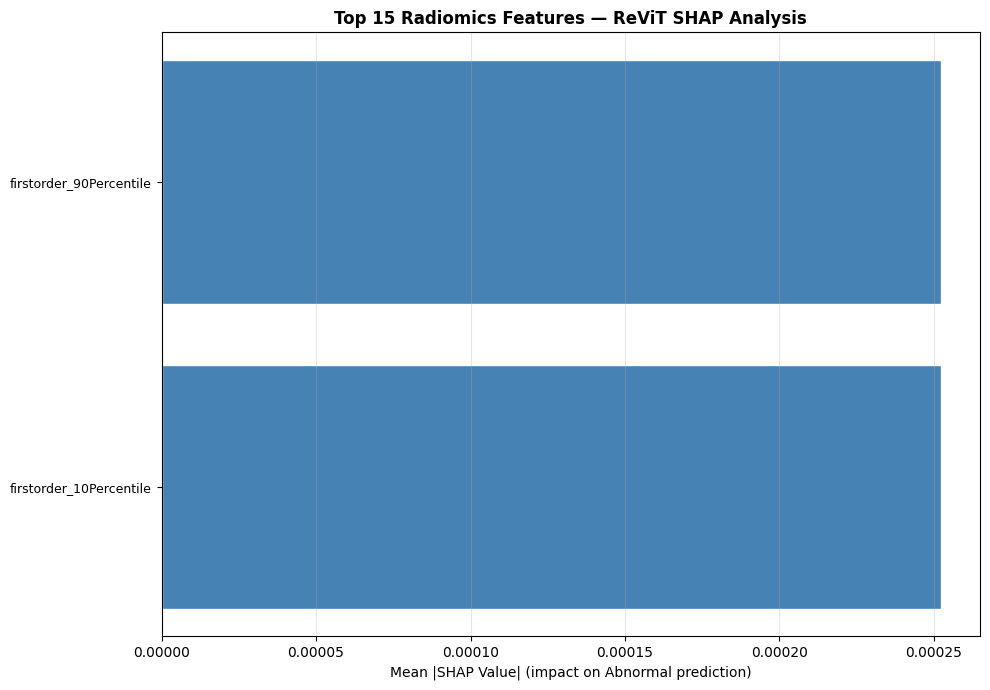

Saved to /content/drive/MyDrive/Ultrasound_Internship/revit_project/outputs/shap_radiomics_importance.png


In [ ]:
# ── Debug: check shapes first ──
print(f"mean_shap shape: {mean_shap.shape}")
print(f"top15_idx shape: {top15_idx.shape}")
print(f"top15_vals: {top15_vals}")
print(f"len top15_names: {len(top15_names_list)}")

# ── Plot 1: Global feature importance bar chart ──
# Use plain floats to avoid any numpy shape issues
vals_to_plot  = [float(v) for v in top15_vals_list]
names_to_plot = top15_names_list

fig, ax = plt.subplots(figsize=(10, 7))
y_pos = np.arange(len(vals_to_plot))

ax.barh(y_pos, vals_to_plot, color='steelblue', edgecolor='white')
ax.set_yticks(y_pos)
ax.set_yticklabels(names_to_plot, fontsize=9)
ax.set_xlabel("Mean |SHAP Value| (impact on Abnormal prediction)", fontsize=10)
ax.set_title("Top 15 Radiomics Features — ReViT SHAP Analysis",
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_SAVE}/shap_radiomics_importance.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {OUTPUT_SAVE}/shap_radiomics_importance.png")

In [ ]:
# Debug SHAP output structure
print(f"Type of shap_vals: {type(shap_vals)}")
print(f"Length of shap_vals: {len(shap_vals)}")

if isinstance(shap_vals, list):
    for i, sv in enumerate(shap_vals):
        print(f"  shap_vals[{i}] shape: {np.array(sv).shape}")
else:
    print(f"shap_vals shape: {np.array(shap_vals).shape}")

Type of shap_vals: <class 'numpy.ndarray'>
Length of shap_vals: 20
shap_vals shape: (20, 93, 2)


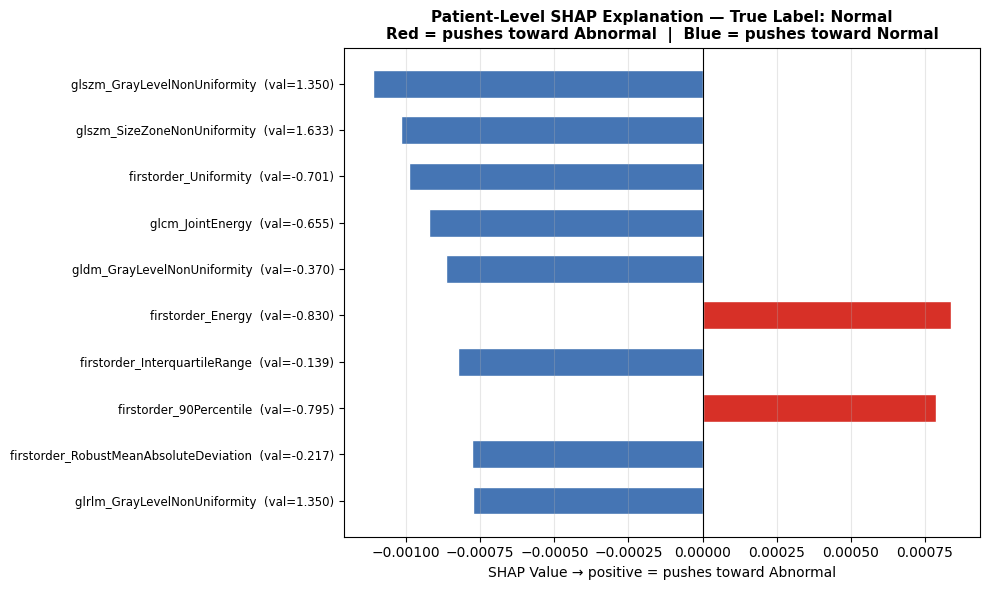

Saved: /content/drive/MyDrive/Ultrasound_Internship/revit_project/outputs/shap_waterfall_normal.png


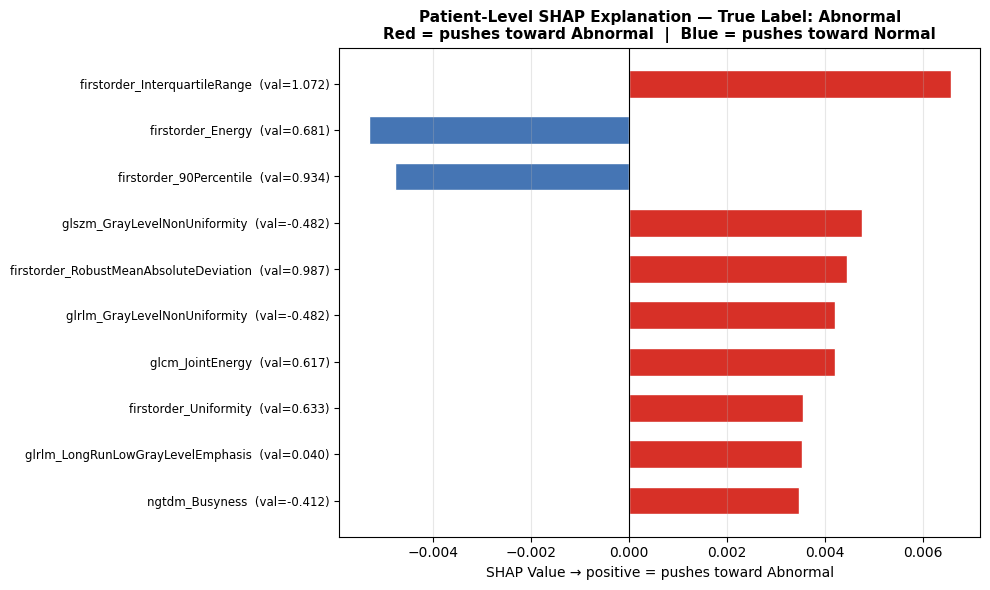

Saved: /content/drive/MyDrive/Ultrasound_Internship/revit_project/outputs/shap_waterfall_abnormal.png


In [ ]:
#original cell 15
# ── Pick one Normal and one Abnormal patient to explain individually ──

normal_test_indices   = [i for i,l in enumerate(y_binary[test_idx]) if l == 0]
abnormal_test_indices = [i for i,l in enumerate(y_binary[test_idx]) if l == 1]

for patient_idx, label_name in [
    (normal_test_indices[0],   "Normal"),
    (abnormal_test_indices[0], "Abnormal")
]:
    shap_single = shap_abnormal[patient_idx]          # [93]
    rad_single  = test_rad_shap[patient_idx].cpu().numpy()  # [93]

    # Get top contributing features for this patient
    top10_idx   = np.argsort(np.abs(shap_single))[::-1][:10]
    top10_names = [feature_names[i].replace('original_','') for i in top10_idx]
    top10_shap  = shap_single[top10_idx]
    top10_vals  = rad_single[top10_idx]

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['#d73027' if v > 0 else '#4575b4' for v in top10_shap]
    bars   = ax.barh(range(10), top10_shap[::-1],
                     color=colors[::-1], edgecolor='white', height=0.6)

    labels_with_vals = [
        f"{n}  (val={v:.3f})"
        for n, v in zip(top10_names[::-1], top10_vals[::-1])
    ]
    ax.set_yticks(range(10))
    ax.set_yticklabels(labels_with_vals, fontsize=8.5)
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.set_xlabel("SHAP Value → positive = pushes toward Abnormal", fontsize=10)
    ax.set_title(
        f"Patient-Level SHAP Explanation — True Label: {label_name}\n"
        f"Red = pushes toward Abnormal  |  Blue = pushes toward Normal",
        fontsize=11, fontweight='bold'
    )
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    fname = f"shap_waterfall_{label_name.lower()}.png"
    plt.savefig(f"{OUTPUT_SAVE}/{fname}", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {OUTPUT_SAVE}/{fname}")

No attention weights returned — using uniform heatmap as fallback
No attention weights returned — using uniform heatmap as fallback
No attention weights returned — using uniform heatmap as fallback
No attention weights returned — using uniform heatmap as fallback


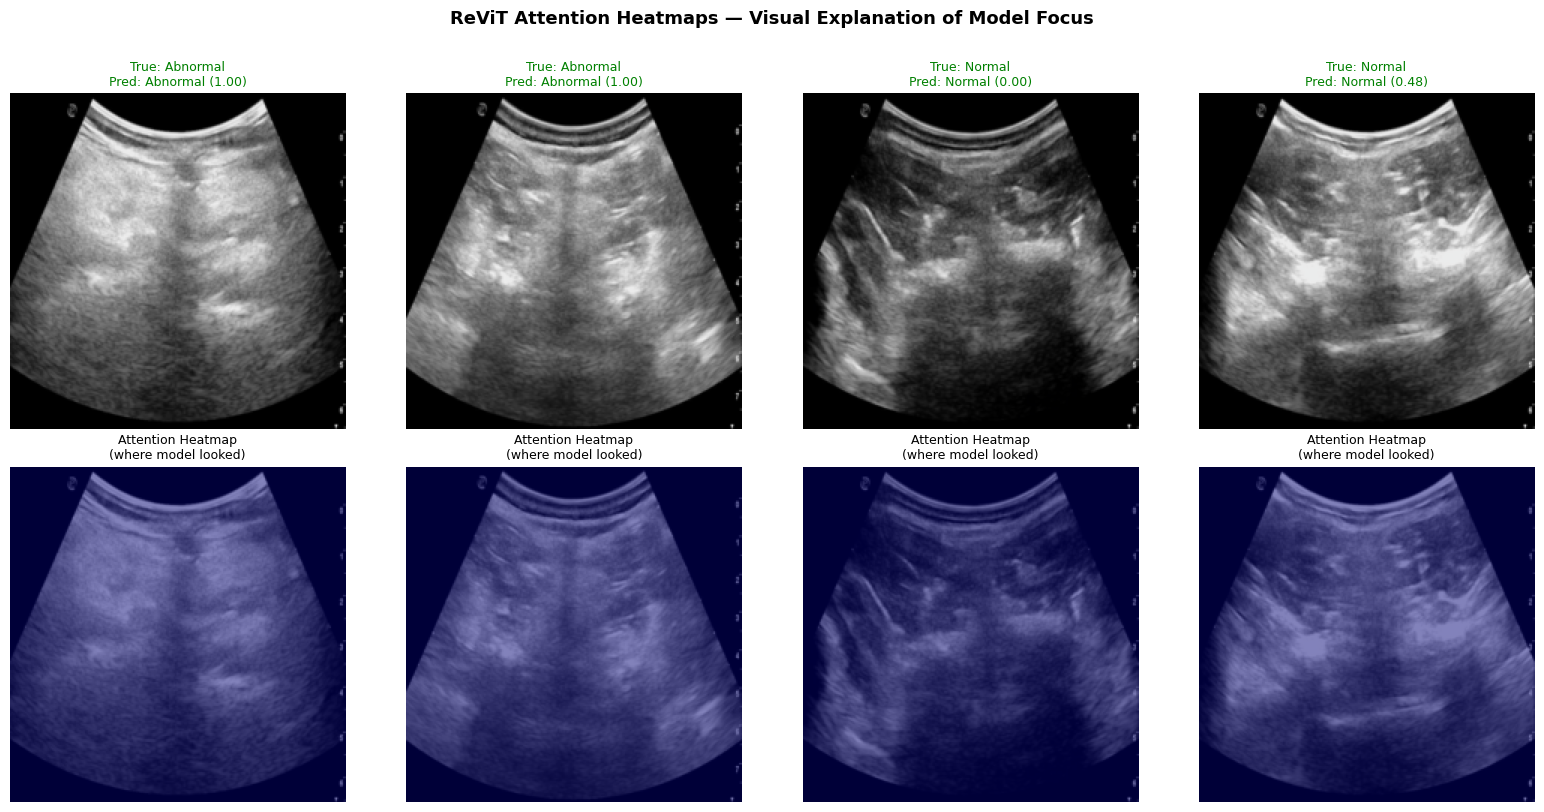

Saved to /content/drive/MyDrive/Ultrasound_Internship/revit_project/outputs/attention_heatmaps.png

All explainability outputs complete!

Files saved in /content/drive/MyDrive/Ultrasound_Internship/revit_project/outputs:
  revit_results.png
  shap_radiomics_importance.png
  shap_beeswarm.png
  shap_waterfall_normal.png
  shap_waterfall_abnormal.png
  attention_heatmaps.png


In [ ]:
#original cell 16
from torchvision.transforms.functional import to_pil_image
import torch.nn.functional as F

def get_attention_heatmap(model, image_tensor, radiomics_tensor, device):
    model.eval()
    img = image_tensor.unsqueeze(0).to(device)
    rad = radiomics_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        # Call ViT directly with output_attentions=True
        vit_out = model.vit(
            pixel_values=img,
            output_attentions=True
        )

    # Check attentions came through
    if vit_out.attentions is None or len(vit_out.attentions) == 0:
        print("No attention weights returned — using uniform heatmap as fallback")
        return np.ones((224, 224)) * 0.5

    # Last layer attention: [1, num_heads, 197, 197]
    last_attn = vit_out.attentions[-1]

    # Average across heads → [197, 197]
    attn_mean = last_attn[0].mean(dim=0)

    # CLS token row → attention over all patches
    cls_attn = attn_mean[0, 1:]            # [196]

    # Reshape to 14x14 patch grid
    patch_grid   = cls_attn.reshape(14, 14).cpu().numpy()

    # Upsample to 224x224
    patch_tensor = torch.tensor(patch_grid).unsqueeze(0).unsqueeze(0)
    heatmap = F.interpolate(patch_tensor, size=(224, 224),
                            mode='bilinear', align_corners=False)
    heatmap = heatmap.squeeze().numpy()

    # Normalise 0-1
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    return heatmap


# ── Plot attention heatmaps for 4 test images ──
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for col, sample_idx in enumerate(abnormal_test_indices[:2] + normal_test_indices[:2]):
    img_tensor, rad_tensor, true_label = test_ds[sample_idx]

    # Get prediction
    model.eval()
    with torch.no_grad():
        logits = model(
            img_tensor.unsqueeze(0).to(device),
            rad_tensor.unsqueeze(0).to(device)
        )
        pred  = torch.argmax(logits, dim=1).item()
        prob  = torch.softmax(logits, dim=-1)[0, 1].item()

    pred_name  = "Abnormal" if pred  == 1 else "Normal"
    true_name  = "Abnormal" if true_label == 1 else "Normal"

    # Get heatmap
    heatmap = get_attention_heatmap(model, img_tensor, rad_tensor, device)

    # Original image (denormalise)
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    orig = img_tensor.numpy().transpose(1,2,0)
    orig = (orig * std + mean).clip(0, 1)

    # Show original
    axes[0, col].imshow(orig)
    axes[0, col].set_title(
        f"True: {true_name}\nPred: {pred_name} ({prob:.2f})",
        fontsize=9,
        color='green' if pred == true_label else 'red'
    )
    axes[0, col].axis('off')

    # Show attention overlay
    axes[1, col].imshow(orig)
    axes[1, col].imshow(heatmap, cmap='jet', alpha=0.45)
    axes[1, col].set_title("Attention Heatmap\n(where model looked)", fontsize=9)
    axes[1, col].axis('off')

plt.suptitle(
    "ReViT Attention Heatmaps — Visual Explanation of Model Focus",
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(f"{OUTPUT_SAVE}/attention_heatmaps.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {OUTPUT_SAVE}/attention_heatmaps.png")
print("\nAll explainability outputs complete!")
print(f"\nFiles saved in {OUTPUT_SAVE}:")
for f in os.listdir(OUTPUT_SAVE):
    print(f"  {f}")